In [1]:
#@title # Model #6: 1D (AAC/CTD features) + Random Forest
# =============================================================================
# Part of the InterPET ablation table:
#   1. 1D, ESM-2, XGBoost   (already done)
#   2. 1D, ESM-2, RF        (already done)
#   3. 1D, ProtT5, XGBoost  (already done)
#   4. 1D, ProtT5, RF       (already done)
#   5. 1D, AAC/CTD, XGBoost (already done)
#   6. 1D, AAC/CTD, RF      <- this notebook
#   7. 1D, Graph (chain edges), GraphSAGE
#   8. 1D+3D, Graph (structure contact-map edges), GraphSAGE
#
# Model #6 is identical to Model #5 in terms of input representation (AAC/
# CTD handcrafted features); the only difference is the classifier: Random
# Forest replaces XGBoost. This is purely an ablation on the choice of
# classifier -- all other methodology (CV, threshold from OOF, single-shot
# benchmark evaluation, metrics, SHAP, mutagenesis scan) is kept identical
# to Model #5 so that the results of both models can be compared fairly
# (apples-to-apples).
#
# Like Model #5, no GPU or protein language model is needed here.


In [2]:
#@title # Mount Google Drive & Install dependencies
from google.colab import drive
drive.mount('/content/drive')

# No protein language model or GPU needed for this notebook -- AAC/CTD
# features are computed directly from the amino acid sequence.
!pip install -q scikit-learn pandas numpy shap tqdm seaborn


Mounted at /content/drive


In [3]:
#@title # 1. Configuration

import os
import numpy as np
import pandas as pd
import pickle
from collections import Counter

PROJECT_ROOT = "/content/drive/MyDrive/InterPET"
DATASETS_DIR = os.path.join(PROJECT_ROOT, "datasets")
MODEL_OUT_DIR = os.path.join(PROJECT_ROOT, "models", "model6_aac_ctd_rf")
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

# Model #5 directory -- used to reuse the AAC/CTD features already computed
# there (Model #5 and #6 have identical input representations, so there is
# no need to recompute them).
MODEL5_OUT_DIR = os.path.join(PROJECT_ROOT, "models", "model5_aac_ctd_xgb")

TRAIN_FINAL_CSV = os.path.join(DATASETS_DIR, "train_final_labels.csv")
BENCHMARK_FINAL_CSV = os.path.join(DATASETS_DIR, "benchmark_final_labels.csv")

N_FOLDS = 5
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

for path in [TRAIN_FINAL_CSV, BENCHMARK_FINAL_CSV]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found. Run the Dataset Curation & QC notebook first.")


In [4]:
#@title # 2. Load curated dataset

df_train = pd.read_csv(TRAIN_FINAL_CSV)
df_bench = pd.read_csv(BENCHMARK_FINAL_CSV)

print(f"Train: {len(df_train)} sequences ({df_train['label'].sum()} positive, {(df_train['label']==0).sum()} negative)")
print(f"Benchmark: {len(df_bench)} sequences ({df_bench['label'].sum()} positive, {(df_bench['label']==0).sum()} negative)")


Train: 937 sequences (403 positive, 534 negative)
Benchmark: 139 sequences (22 positive, 117 negative)


In [5]:
#@title # Resume from checkpoint (skip AAC/CTD feature extraction)
# Run this INSTEAD of sections 3-6 (AAC/CTD feature extraction, hyperparameter search,
# threshold optimization, final model training) if those already ran once
# before and you only want to redo visualization/interpretability (section 7
# onward) -- e.g. after a runtime restart, or when just tweaking plotting/
# analysis code. The "Mount Google Drive & Install dependencies" cell,
# section 1 (config), and section 2 (load dataset, for df_train/df_bench)
# still need to run first.

import json
import pickle
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score, average_precision_score,
    confusion_matrix, accuracy_score, matthews_corrcoef,
)
from sklearn.ensemble import RandomForestClassifier

X_train_full = np.load(os.path.join(MODEL_OUT_DIR, "X_train_aac_ctd.npy"))
X_bench = np.load(os.path.join(MODEL_OUT_DIR, "X_bench_aac_ctd.npy"))
y_train_full = df_train["label"].astype(int).to_numpy()
y_bench = df_bench["label"].astype(int).to_numpy()

with open(os.path.join(MODEL_OUT_DIR, "feature_names.pkl"), "rb") as f:
    FEATURE_NAMES = pickle.load(f)

with open(os.path.join(MODEL_OUT_DIR, "best_params.json")) as f:
    best_params = json.load(f)

with open(os.path.join(MODEL_OUT_DIR, "chosen_threshold.txt")) as f:
    best_threshold = float(f.read())

with open(os.path.join(MODEL_OUT_DIR, "final_model.pkl"), "rb") as f:
    final_model = pickle.load(f)

oof_proba = np.load(os.path.join(MODEL_OUT_DIR, "oof_proba.npy"))
y_bench_proba = np.load(os.path.join(MODEL_OUT_DIR, "y_bench_proba.npy"))
y_bench_pred = np.load(os.path.join(MODEL_OUT_DIR, "y_bench_pred.npy"))

bench_metrics = pd.read_csv(
    os.path.join(MODEL_OUT_DIR, "benchmark_metrics.csv"), index_col=0
).squeeze("columns").to_dict()

# Re-create the CV splitter (deterministic given the same random_state, so
# this reproduces the exact same folds without retraining anything).
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Cheap to recompute from oof_proba (no retraining involved) -- needed for
# the "F1 vs threshold" plot in section 10.
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y_train_full, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds]
oof_pred = (oof_proba >= best_threshold).astype(int)

# Needed later for the mutagenesis sections -- AAC/CTD feature computation
# is pure Python (no model to reload), so we just redefine the feature
# functions here (identical to section 3).
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"

AA_GROUPS = {
    "Hydrophobicity":          {1: "RKEDQN",           2: "GASTPHY",           3: "CLVIMFW"},
    "NormVanDerWaalsVolume":   {1: "GASTPDC",           2: "NVEQIL",            3: "MHKFRYW"},
    "Polarity":                {1: "LIFWCMVY",          2: "PATGS",             3: "HQRKNED"},
    "Polarizability":          {1: "GASDT",             2: "CPNVEQIL",          3: "KMHFRYW"},
    "Charge":                  {1: "KR",                2: "ANCQGHILMFPSTWYV",  3: "DE"},
    "SecondaryStructure":      {1: "EALMQKRH",          2: "VIYCWFT",           3: "GNPSD"},
    "SolventAccessibility":    {1: "ALFCGIVW",          2: "RKQEND",            3: "MPSTHY"},
}


def clean_sequence(seq):
    seq = seq.strip().upper()
    return "".join(c for c in seq if c in AMINO_ACIDS)


def compute_aac(seq):
    seq = clean_sequence(seq)
    n = len(seq)
    counts = Counter(seq)
    return {f"AAC_{aa}": (counts.get(aa, 0) / n if n else 0.0) for aa in AMINO_ACIDS}


def _group_sequence(seq, groups):
    mapping = {aa: g for g, aas in groups.items() for aa in aas}
    return [mapping[aa] for aa in seq if aa in mapping]


def get_ctd_feature_names():
    names = []
    for prop in AA_GROUPS:
        names += [f"{prop}_C{g}" for g in (1, 2, 3)]
        names += [f"{prop}_T12", f"{prop}_T13", f"{prop}_T23"]
        for g in (1, 2, 3):
            names += [f"{prop}_group{g}_{label}" for label in ("D0", "D25", "D50", "D75", "D100")]
    return names


CTD_FEATURE_NAMES = get_ctd_feature_names()


def compute_ctd(seq):
    seq = clean_sequence(seq)
    L = len(seq)
    if L == 0:
        return {name: 0.0 for name in CTD_FEATURE_NAMES}

    features = {}
    for prop, groups in AA_GROUPS.items():
        gseq = _group_sequence(seq, groups)
        gL = len(gseq)

        for g in (1, 2, 3):
            features[f"{prop}_C{g}"] = (gseq.count(g) / gL) if gL else 0.0

        trans_counts = {(1, 2): 0, (1, 3): 0, (2, 3): 0}
        for i in range(gL - 1):
            pair = tuple(sorted((gseq[i], gseq[i + 1])))
            if pair[0] != pair[1] and pair in trans_counts:
                trans_counts[pair] += 1
        denom = (gL - 1) if gL > 1 else 1
        features[f"{prop}_T12"] = trans_counts[(1, 2)] / denom
        features[f"{prop}_T13"] = trans_counts[(1, 3)] / denom
        features[f"{prop}_T23"] = trans_counts[(2, 3)] / denom

        for g in (1, 2, 3):
            positions = [i for i, x in enumerate(gseq) if x == g]
            n_g = len(positions)
            for pct, label in zip((0, 25, 50, 75, 100), ("D0", "D25", "D50", "D75", "D100")):
                if n_g == 0:
                    features[f"{prop}_group{g}_{label}"] = 0.0
                else:
                    idx = min(max(0, int(np.ceil(pct / 100 * n_g)) - 1), n_g - 1)
                    features[f"{prop}_group{g}_{label}"] = (positions[idx] + 1) / gL * 100

    return features


def compute_features(seq):
    feats = {}
    feats.update(compute_aac(seq))
    feats.update(compute_ctd(seq))
    return np.array([feats[name] for name in FEATURE_NAMES], dtype=float)


def get_features_batch(sequences):
    return np.vstack([compute_features(s) for s in sequences])

print("Checkpoint loaded -- ready to jump to section 7 (visualization & interpretability).")
print(f"X_train_full: {X_train_full.shape}, X_bench: {X_bench.shape}")
print(f"best_params: {best_params}")
print(f"best_threshold: {best_threshold:.2f}")
print("Benchmark metrics:", bench_metrics)


Checkpoint loaded -- ready to jump to section 7 (visualization & interpretability).
X_train_full: (937, 167), X_bench: (139, 167)
best_params: {'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
best_threshold: 0.51
Benchmark metrics: {'accuracy': 0.8992805755395683, 'precision': 0.6333333333333333, 'recall': 0.8636363636363636, 'f1': 0.7307692307692307, 'auc': 0.9514374514374514, 'pr_auc': 0.7155945849686487, 'mcc': 0.6828201488627126}


In [ ]:
#@title # 3. Extract AAC/CTD features (handcrafted, no GPU required) -- reuse Model #5 cache if available

# AAC: Amino Acid Composition -- fraction of each of the 20 standard amino
# acids in the sequence (20 features).
#
# CTD: Composition / Transition / Distribution of 7 physicochemical
# property groups (Dubchak et al. 1995/1999), each amino acid classified
# into 1 of 3 groups per property (147 features). See Model #5 for the
# full definitions.
# Total feature vector: 20 (AAC) + 147 (CTD) = 167 features.

AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"

AA_GROUPS = {
    "Hydrophobicity":          {1: "RKEDQN",           2: "GASTPHY",           3: "CLVIMFW"},
    "NormVanDerWaalsVolume":   {1: "GASTPDC",           2: "NVEQIL",            3: "MHKFRYW"},
    "Polarity":                {1: "LIFWCMVY",          2: "PATGS",             3: "HQRKNED"},
    "Polarizability":          {1: "GASDT",             2: "CPNVEQIL",          3: "KMHFRYW"},
    "Charge":                  {1: "KR",                2: "ANCQGHILMFPSTWYV",  3: "DE"},
    "SecondaryStructure":      {1: "EALMQKRH",          2: "VIYCWFT",           3: "GNPSD"},
    "SolventAccessibility":    {1: "ALFCGIVW",          2: "RKQEND",            3: "MPSTHY"},
}


def clean_sequence(seq):
    seq = seq.strip().upper()
    return "".join(c for c in seq if c in AMINO_ACIDS)


def compute_aac(seq):
    seq = clean_sequence(seq)
    n = len(seq)
    counts = Counter(seq)
    return {f"AAC_{aa}": (counts.get(aa, 0) / n if n else 0.0) for aa in AMINO_ACIDS}


def _group_sequence(seq, groups):
    mapping = {aa: g for g, aas in groups.items() for aa in aas}
    return [mapping[aa] for aa in seq if aa in mapping]


def get_ctd_feature_names():
    names = []
    for prop in AA_GROUPS:
        names += [f"{prop}_C{g}" for g in (1, 2, 3)]
        names += [f"{prop}_T12", f"{prop}_T13", f"{prop}_T23"]
        for g in (1, 2, 3):
            names += [f"{prop}_group{g}_{label}" for label in ("D0", "D25", "D50", "D75", "D100")]
    return names


CTD_FEATURE_NAMES = get_ctd_feature_names()


def compute_ctd(seq):
    seq = clean_sequence(seq)
    L = len(seq)
    if L == 0:
        return {name: 0.0 for name in CTD_FEATURE_NAMES}

    features = {}
    for prop, groups in AA_GROUPS.items():
        gseq = _group_sequence(seq, groups)
        gL = len(gseq)

        for g in (1, 2, 3):
            features[f"{prop}_C{g}"] = (gseq.count(g) / gL) if gL else 0.0

        trans_counts = {(1, 2): 0, (1, 3): 0, (2, 3): 0}
        for i in range(gL - 1):
            pair = tuple(sorted((gseq[i], gseq[i + 1])))
            if pair[0] != pair[1] and pair in trans_counts:
                trans_counts[pair] += 1
        denom = (gL - 1) if gL > 1 else 1
        features[f"{prop}_T12"] = trans_counts[(1, 2)] / denom
        features[f"{prop}_T13"] = trans_counts[(1, 3)] / denom
        features[f"{prop}_T23"] = trans_counts[(2, 3)] / denom

        for g in (1, 2, 3):
            positions = [i for i, x in enumerate(gseq) if x == g]
            n_g = len(positions)
            for pct, label in zip((0, 25, 50, 75, 100), ("D0", "D25", "D50", "D75", "D100")):
                if n_g == 0:
                    features[f"{prop}_group{g}_{label}"] = 0.0
                else:
                    idx = min(max(0, int(np.ceil(pct / 100 * n_g)) - 1), n_g - 1)
                    features[f"{prop}_group{g}_{label}"] = (positions[idx] + 1) / gL * 100

    return features


FEATURE_NAMES = [f"AAC_{aa}" for aa in AMINO_ACIDS] + CTD_FEATURE_NAMES


def compute_features(seq):
    feats = {}
    feats.update(compute_aac(seq))
    feats.update(compute_ctd(seq))
    return np.array([feats[name] for name in FEATURE_NAMES], dtype=float)


def get_features_batch(sequences):
    return np.vstack([compute_features(s) for s in sequences])


cached_train_path = os.path.join(MODEL5_OUT_DIR, "X_train_aac_ctd.npy")
cached_bench_path = os.path.join(MODEL5_OUT_DIR, "X_bench_aac_ctd.npy")

if os.path.exists(cached_train_path) and os.path.exists(cached_bench_path):
    print("Found feature cache from Model #5 -- reusing directly (no need to recompute AAC/CTD).")
    X_train_full = np.load(cached_train_path)
    X_bench = np.load(cached_bench_path)
    y_train_full = df_train["label"].astype(int).to_numpy()
    y_bench = df_bench["label"].astype(int).to_numpy()
    print(f"X_train_full: {X_train_full.shape}, X_bench: {X_bench.shape}")
else:
    print("Model #5 cache not found -- computing AAC/CTD features from scratch.")
    print(f"Total AAC/CTD features: {len(FEATURE_NAMES)} (20 AAC + {len(CTD_FEATURE_NAMES)} CTD)")

    print("\nComputing training set features...")
    X_train_full = get_features_batch(df_train["sequence"].tolist())
    y_train_full = df_train["label"].astype(int).to_numpy()
    print(f"Shape: {X_train_full.shape}")

    print("\nComputing benchmark set features...")
    X_bench = get_features_batch(df_bench["sequence"].tolist())
    y_bench = df_bench["label"].astype(int).to_numpy()
    print(f"Shape: {X_bench.shape}")

    np.save(os.path.join(MODEL_OUT_DIR, "X_train_aac_ctd.npy"), X_train_full)
    np.save(os.path.join(MODEL_OUT_DIR, "X_bench_aac_ctd.npy"), X_bench)

# Make sure a copy of the features also lives in THIS model's own
# MODEL_OUT_DIR (not just Model #5's), so the "Resume from checkpoint" cell
# below can always find them here regardless of whether they were reused
# from cache or computed fresh.
own_train_path = os.path.join(MODEL_OUT_DIR, "X_train_aac_ctd.npy")
own_bench_path = os.path.join(MODEL_OUT_DIR, "X_bench_aac_ctd.npy")
if not os.path.exists(own_train_path):
    np.save(own_train_path, X_train_full)
if not os.path.exists(own_bench_path):
    np.save(own_bench_path, X_bench)

with open(os.path.join(MODEL_OUT_DIR, "feature_names.pkl"), "wb") as f:
    pickle.dump(FEATURE_NAMES, f)


Found feature cache from Model #5 -- reusing directly (no need to recompute AAC/CTD).
X_train_full: (937, 167), X_bench: (139, 167)


In [ ]:
#@title # 4. Hyperparameter search (Stratified K-Fold CV) -- Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

# Random Forest does not have a scale_pos_weight like XGBoost -- imbalance
# handling is done via class_weight="balanced" (conceptually equivalent).
# Same param grid as Model #2/#4.
param_grid = [
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": 10,   "min_samples_leaf": 2, "max_features": "sqrt"},
    {"n_estimators": 500, "max_depth": 20,   "min_samples_leaf": 1, "max_features": "log2"},
    {"n_estimators": 500, "max_depth": None, "min_samples_leaf": 4, "max_features": "sqrt"},
    {"n_estimators": 800, "max_depth": 15,   "min_samples_leaf": 2, "max_features": "log2"},
]

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

n_pos = y_train_full.sum()
n_neg = len(y_train_full) - n_pos
print(f"Class balance -- positive: {n_pos}, negative: {n_neg} (class_weight='balanced' will be used)")

best_params, best_cv_f1 = None, -1
cv_results_log = []

for params in param_grid:
    fold_f1s = []
    for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X_train_full, y_train_full)):
        model = RandomForestClassifier(
            **params, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1,
        )
        model.fit(X_train_full[tr_idx], y_train_full[tr_idx])
        proba = model.predict_proba(X_train_full[va_idx])[:, 1]
        pred = (proba >= 0.5).astype(int)
        fold_f1s.append(f1_score(y_train_full[va_idx], pred, zero_division=0))

    mean_f1 = np.mean(fold_f1s)
    cv_results_log.append({**params, "cv_f1_mean": mean_f1, "cv_f1_std": np.std(fold_f1s)})
    print(f"  params={params} -> CV F1 = {mean_f1:.4f} (+/- {np.std(fold_f1s):.4f})")

    if mean_f1 > best_cv_f1:
        best_cv_f1 = mean_f1
        best_params = params

print(f"\nBest params: {best_params}")
print(f"Best CV F1: {best_cv_f1:.4f}")

pd.DataFrame(cv_results_log).to_csv(os.path.join(MODEL_OUT_DIR, "cv_hyperparam_search.csv"), index=False)

import json
with open(os.path.join(MODEL_OUT_DIR, "best_params.json"), "w") as f:
    json.dump(best_params, f)


Class balance -- positive: 403, negative: 534 (class_weight='balanced' will be used)
  params={'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt'} -> CV F1 = 0.9145 (+/- 0.0431)
  params={'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt'} -> CV F1 = 0.9159 (+/- 0.0436)
  params={'n_estimators': 500, 'max_depth': 20, 'min_samples_leaf': 1, 'max_features': 'log2'} -> CV F1 = 0.9147 (+/- 0.0447)
  params={'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 4, 'max_features': 'sqrt'} -> CV F1 = 0.9106 (+/- 0.0454)
  params={'n_estimators': 800, 'max_depth': 15, 'min_samples_leaf': 2, 'max_features': 'log2'} -> CV F1 = 0.9135 (+/- 0.0480)

Best params: {'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
Best CV F1: 0.9159


In [ ]:
#@title # 5. Threshold optimization via OUT-OF-FOLD predictions (not from the benchmark!)

# Same as Model #1-5: the threshold is chosen from out-of-fold (OOF)
# predictions, NOT peeked from the benchmark, to avoid data leakage.

oof_proba = np.zeros(len(y_train_full))

for tr_idx, va_idx in skf.split(X_train_full, y_train_full):
    model = RandomForestClassifier(
        **best_params, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1,
    )
    model.fit(X_train_full[tr_idx], y_train_full[tr_idx])
    oof_proba[va_idx] = model.predict_proba(X_train_full[va_idx])[:, 1]

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y_train_full, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"OOF F1 across thresholds -- best: {best_threshold:.2f} (F1={max(f1_scores):.4f})")
print("\nDetailed OOF metrics at the best threshold:")
oof_pred = (oof_proba >= best_threshold).astype(int)
print(f"  F1        : {f1_score(y_train_full, oof_pred):.4f}")
print(f"  Precision : {precision_score(y_train_full, oof_pred):.4f}")
print(f"  Recall    : {recall_score(y_train_full, oof_pred):.4f}")
print(f"  AUC       : {roc_auc_score(y_train_full, oof_proba):.4f}")
print(f"  PR-AUC    : {average_precision_score(y_train_full, oof_proba):.4f}")

with open(os.path.join(MODEL_OUT_DIR, "chosen_threshold.txt"), "w") as f:
    f.write(str(best_threshold))

np.save(os.path.join(MODEL_OUT_DIR, "oof_proba.npy"), oof_proba)


OOF F1 across thresholds -- best: 0.51 (F1=0.9192)

Detailed OOF metrics at the best threshold:
  F1        : 0.9192
  Precision : 0.9858
  Recall    : 0.8610
  AUC       : 0.9532
  PR-AUC    : 0.9582


In [ ]:
#@title # 6. Train final model (full training set) & evaluate ONCE on the benchmark

final_model = RandomForestClassifier(
    **best_params, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1,
)
final_model.fit(X_train_full, y_train_full)

y_bench_proba = final_model.predict_proba(X_bench)[:, 1]
y_bench_pred = (y_bench_proba >= best_threshold).astype(int)

from sklearn.metrics import confusion_matrix, accuracy_score, matthews_corrcoef

bench_metrics = {
    "accuracy": accuracy_score(y_bench, y_bench_pred),
    "precision": precision_score(y_bench, y_bench_pred, zero_division=0),
    "recall": recall_score(y_bench, y_bench_pred, zero_division=0),
    "f1": f1_score(y_bench, y_bench_pred, zero_division=0),
    "auc": roc_auc_score(y_bench, y_bench_proba),
    "pr_auc": average_precision_score(y_bench, y_bench_proba),
    "mcc": matthews_corrcoef(y_bench, y_bench_pred),
}

print("=" * 60)
print("MODEL #6: 1D + AAC/CTD + Random Forest -- BENCHMARK RESULTS")
print(f"(threshold={best_threshold:.2f}, chosen from OOF -- not from the benchmark)")
print("=" * 60)
for k, v in bench_metrics.items():
    print(f"  {k:<10}: {v:.4f}")

cm = confusion_matrix(y_bench, y_bench_pred)
print(f"\nConfusion Matrix:")
print(f"  TP: {cm[1,1]}, FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]}, TN: {cm[0,0]}")

pd.Series(bench_metrics).to_csv(os.path.join(MODEL_OUT_DIR, "benchmark_metrics.csv"))

with open(os.path.join(MODEL_OUT_DIR, "final_model.pkl"), "wb") as f:
    pickle.dump(final_model, f)
np.save(os.path.join(MODEL_OUT_DIR, "y_bench_proba.npy"), y_bench_proba)
np.save(os.path.join(MODEL_OUT_DIR, "y_bench_pred.npy"), y_bench_pred)


MODEL #6: 1D + AAC/CTD + Random Forest -- BENCHMARK RESULTS
(threshold=0.51, chosen from OOF -- not from the benchmark)
  accuracy  : 0.8993
  precision : 0.6333
  recall    : 0.8636
  f1        : 0.7308
  auc       : 0.9514
  pr_auc    : 0.7156
  mcc       : 0.6828

Confusion Matrix:
  TP: 19, FP: 11
  FN: 3, TN: 106


In [6]:
#@title # 7. Additional imports for visualization & interpretability
!pip install -q seaborn shap

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
import shap

sns.set_style("whitegrid")


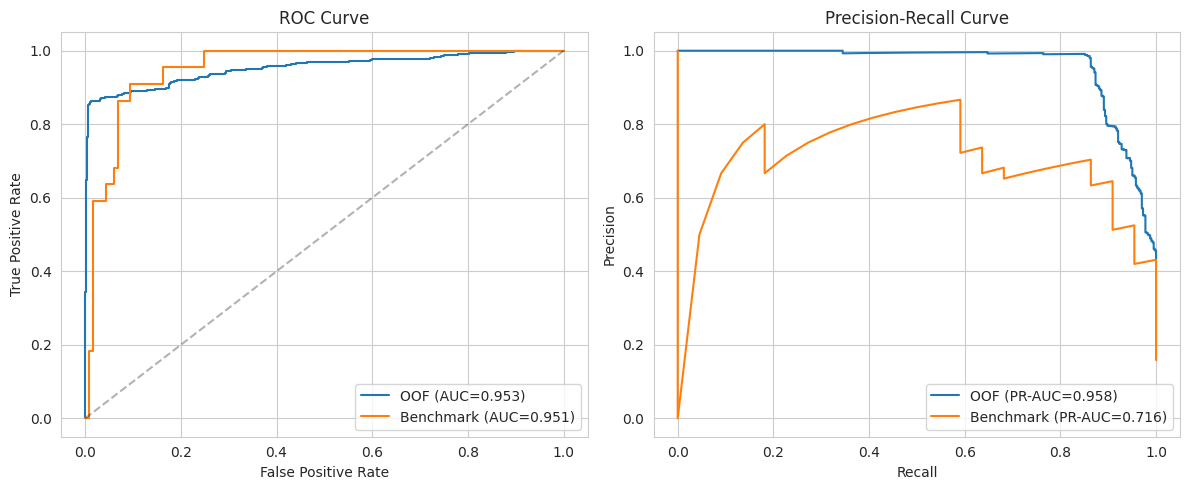

In [7]:
#@title # 8. ROC and Precision-Recall curves (OOF vs Benchmark)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr_oof, tpr_oof, _ = roc_curve(y_train_full, oof_proba)
fpr_bench, tpr_bench, _ = roc_curve(y_bench, y_bench_proba)
axes[0].plot(fpr_oof, tpr_oof, label=f"OOF (AUC={roc_auc_score(y_train_full, oof_proba):.3f})")
axes[0].plot(fpr_bench, tpr_bench, label=f"Benchmark (AUC={bench_metrics['auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

prec_oof, rec_oof, _ = precision_recall_curve(y_train_full, oof_proba)
prec_bench, rec_bench, _ = precision_recall_curve(y_bench, y_bench_proba)
axes[1].plot(rec_oof, prec_oof, label=f"OOF (PR-AUC={average_precision_score(y_train_full, oof_proba):.3f})")
axes[1].plot(rec_bench, prec_bench, label=f"Benchmark (PR-AUC={bench_metrics['pr_auc']:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "roc_pr_curves.png"), dpi=600)
plt.show()


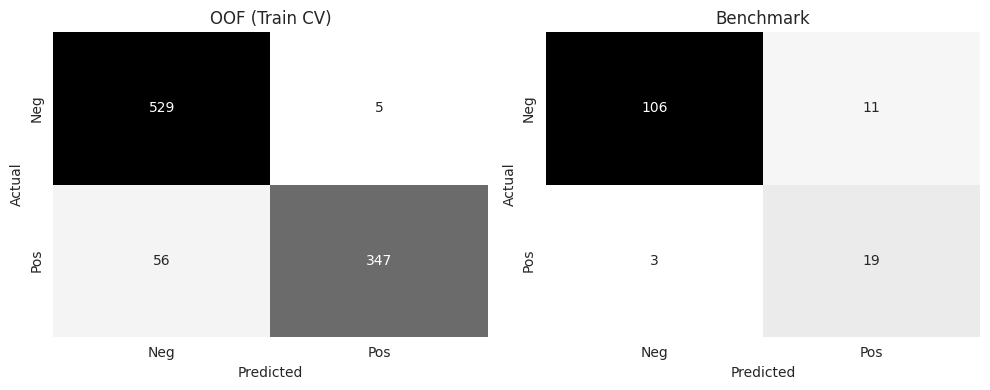

In [8]:
#@title # 9. Confusion matrix heatmaps (OOF vs Benchmark)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_oof = confusion_matrix(y_train_full, oof_pred)
cm_bench_ = confusion_matrix(y_bench, y_bench_pred)

for ax, cm, title in zip(axes, [cm_oof, cm_bench_], ["OOF (Train CV)", "Benchmark"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greys", cbar=False,
                xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "confusion_matrices.png"), dpi=600)
plt.show()


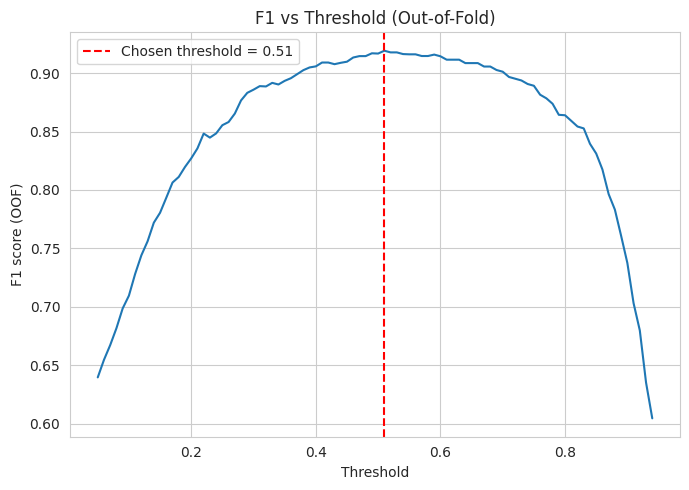

In [9]:
#@title # 10. F1 score vs threshold (OOF)
plt.figure(figsize=(7, 5))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color="red", linestyle="--",
            label=f"Chosen threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 score (OOF)")
plt.title("F1 vs Threshold (Out-of-Fold)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "f1_vs_threshold.png"), dpi=600)
plt.show()


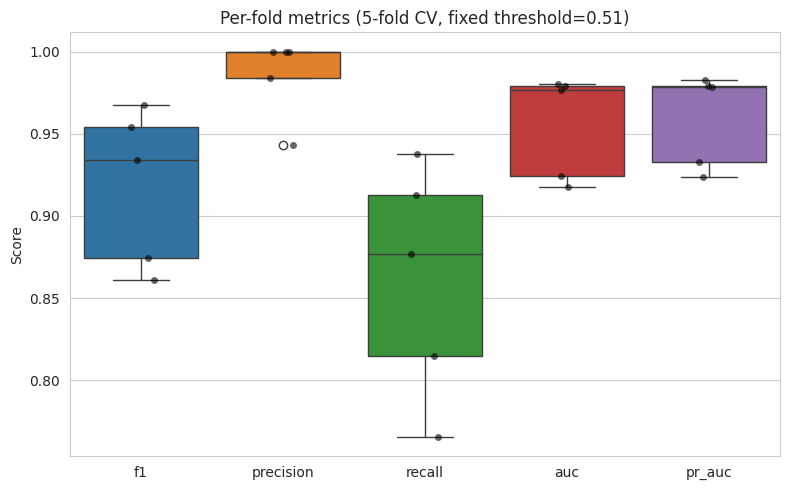

            f1  precision    recall       auc    pr_auc
mean  0.918297   0.985397  0.861358  0.955476  0.959323
std   0.047979   0.024754  0.070731  0.031819  0.028813


In [10]:
#@title # 11. Per-fold metrics with best hyperparameters (multi-metric)
fold_metrics = {"f1": [], "precision": [], "recall": [], "auc": [], "pr_auc": []}

for tr_idx, va_idx in skf.split(X_train_full, y_train_full):
    model = RandomForestClassifier(
        **best_params, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1,
    )
    model.fit(X_train_full[tr_idx], y_train_full[tr_idx])
    proba = model.predict_proba(X_train_full[va_idx])[:, 1]
    pred = (proba >= best_threshold).astype(int)

    fold_metrics["f1"].append(f1_score(y_train_full[va_idx], pred, zero_division=0))
    fold_metrics["precision"].append(precision_score(y_train_full[va_idx], pred, zero_division=0))
    fold_metrics["recall"].append(recall_score(y_train_full[va_idx], pred, zero_division=0))
    fold_metrics["auc"].append(roc_auc_score(y_train_full[va_idx], proba))
    fold_metrics["pr_auc"].append(average_precision_score(y_train_full[va_idx], proba))

fold_metrics_df = pd.DataFrame(fold_metrics)
fold_metrics_df.to_csv(os.path.join(MODEL_OUT_DIR, "cv_fold_metrics.csv"), index=False)

plt.figure(figsize=(8, 5))
sns.boxplot(data=fold_metrics_df)
sns.stripplot(data=fold_metrics_df, color="black", size=5, alpha=0.6)
plt.ylabel("Score")
plt.title(f"Per-fold metrics ({N_FOLDS}-fold CV, fixed threshold={best_threshold:.2f})")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "cv_fold_metrics_boxplot.png"), dpi=600)
plt.show()

print(fold_metrics_df.describe().loc[["mean", "std"]])


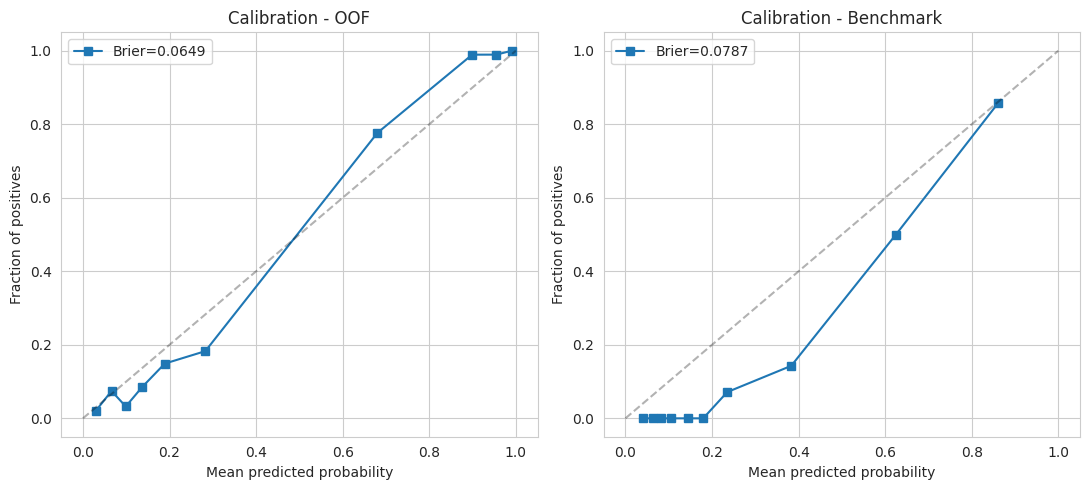

In [11]:
#@title # 12. Calibration curve & Brier score
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, proba, y_true, title in zip(
    axes, [oof_proba, y_bench_proba], [y_train_full, y_bench], ["OOF", "Benchmark"]
):
    frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "s-", label=f"Brier={brier_score_loss(y_true, proba):.4f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(f"Calibration - {title}")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "calibration_curves.png"), dpi=600)
plt.show()


False Positives: 11
                                   sequence  pred_proba  seq_len
MTLTSTLRRQTRTTATATVLAAAAALALCAAPASAQQTGP...    0.958678      293
MHLPRSRWDIPFKEETTMTHHFSVRALLAAGALLASAAVS...    0.887109      304
MVRSMRSRVVAAAVACAMSGAQFAGTTAVMTLATTHAATA...    0.621881      370
MARTMRSRVVAGAVACAMSIAPFAGTTAVMTLATTHAAMA...    0.584175      364
MTASTTRQRISARRLGLRRATLGVATAGLVAAMFTAASAQ...    0.557180      269
MFQRVWALTAALMLMLSLGATSSHAAQNPHERGPDPSNSY...    0.528054      284
MKRRLIAYSIAALAISATAVALPTGVASAAPCSDVDVSFA...    0.669732      216
MNLVGHSQGGLTSRYVAAVAPDLVASVTTIGTPHRGSEFA...    0.547619      240
MVRSMRSRVVAAAVACAMSGAQFAGTTAVMTLATTHAATA...    0.621211      370
MGLAIAAAAVFSLPGVATATEPTGGVQPNIVGGGNATQVY...    0.711891      241
MSTASQTYSPWDIRATAGLSPVATCLILIAMGPSCAKILS...    0.718251      428

False Negatives: 3
                                   sequence  pred_proba  seq_len
MANPYERGPNPTDALLEARSGPFSVSEENVSRLSASGFGG...    0.506207      262
MLIRPVTFRNMNQQIIGILHTPDNIRLNEKVPGILMFHGF...    0.2

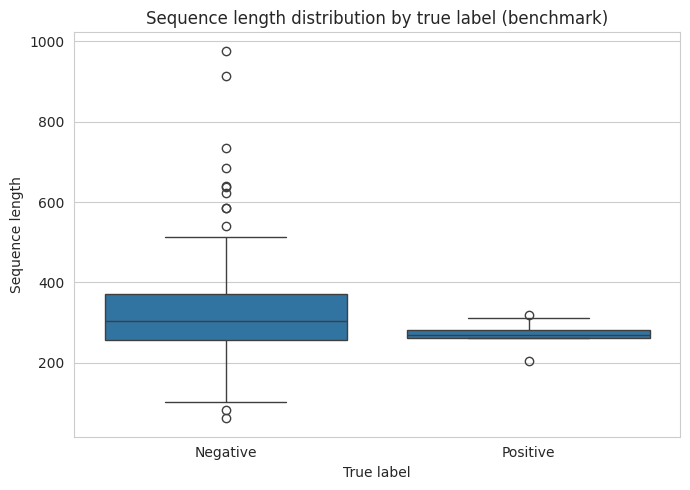

In [12]:
#@title # 13. Error analysis on the benchmark set
df_bench_result = df_bench.copy().reset_index(drop=True)
df_bench_result["pred_proba"] = y_bench_proba
df_bench_result["pred_label"] = y_bench_pred
df_bench_result["seq_len"] = df_bench_result["sequence"].str.len()

false_pos = df_bench_result[(df_bench_result["label"] == 0) & (df_bench_result["pred_label"] == 1)]
false_neg = df_bench_result[(df_bench_result["label"] == 1) & (df_bench_result["pred_label"] == 0)]

print(f"False Positives: {len(false_pos)}")
print(false_pos[["sequence", "pred_proba", "seq_len"]].assign(
    sequence=lambda d: d["sequence"].str[:40] + "..."
).to_string(index=False))

print(f"\nFalse Negatives: {len(false_neg)}")
print(false_neg[["sequence", "pred_proba", "seq_len"]].assign(
    sequence=lambda d: d["sequence"].str[:40] + "..."
).to_string(index=False))

df_bench_result.to_csv(os.path.join(MODEL_OUT_DIR, "benchmark_predictions_detailed.csv"), index=False)

plt.figure(figsize=(7, 5))
sns.boxplot(x="label", y="seq_len", data=df_bench_result)
plt.xticks([0, 1], ["Negative", "Positive"])
plt.xlabel("True label")
plt.ylabel("Sequence length")
plt.title("Sequence length distribution by true label (benchmark)")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "seq_len_by_label.png"), dpi=600)
plt.show()


In [13]:

#@title # 14. Bootstrap confidence intervals for benchmark metrics
# The benchmark set is small (n=139), so point estimates alone can be
# misleading. Bootstrap resampling gives a 95% CI for each metric.

def bootstrap_metric(y_true, values, metric_fn, n_boot=2000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], values[idx]))
    return np.mean(scores), np.percentile(scores, [2.5, 97.5])

metrics_to_bootstrap = {
    "f1": (f1_score, y_bench_pred),
    "precision": (precision_score, y_bench_pred),
    "recall": (recall_score, y_bench_pred),
    "auc": (roc_auc_score, y_bench_proba),
    "pr_auc": (average_precision_score, y_bench_proba),
}

print("Benchmark metrics with 95% bootstrap CI (n_boot=2000):")
ci_results = {}
for name, (fn, vals) in metrics_to_bootstrap.items():
    mean, (lo, hi) = bootstrap_metric(y_bench, vals, fn)
    ci_results[name] = {"mean": mean, "ci_low": lo, "ci_high": hi}
    print(f"  {name:<10}: {mean:.4f}  [{lo:.4f}, {hi:.4f}]")

pd.DataFrame(ci_results).T.to_csv(os.path.join(MODEL_OUT_DIR, "benchmark_metrics_bootstrap_ci.csv"))


Benchmark metrics with 95% bootstrap CI (n_boot=2000):
  f1        : 0.7275  [0.5714, 0.8621]
  precision : 0.6355  [0.4571, 0.8214]
  recall    : 0.8620  [0.7000, 1.0000]
  auc       : 0.9518  [0.9105, 0.9833]
  pr_auc    : 0.7429  [0.5378, 0.9288]


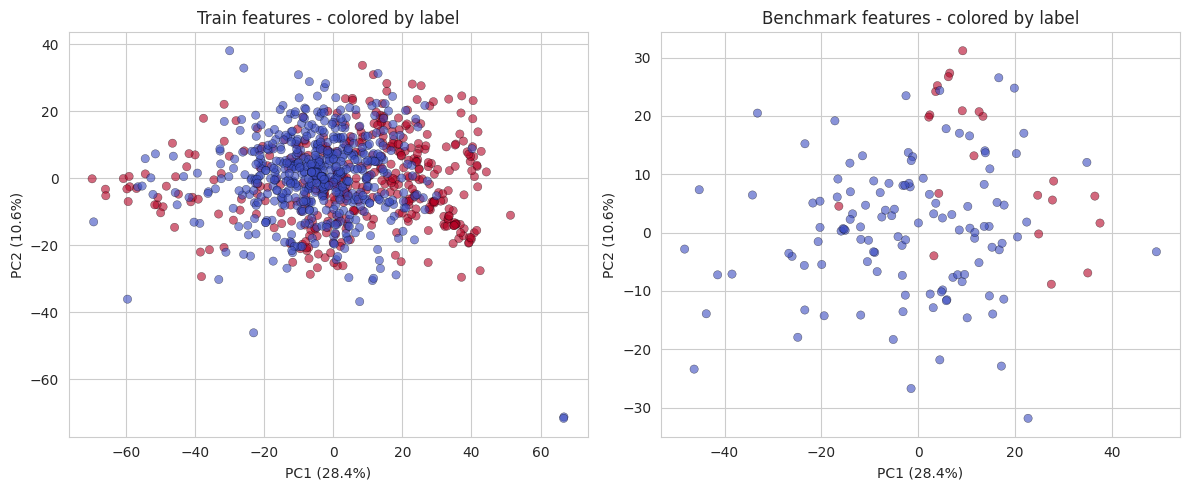

In [14]:
#@title # 15. PCA visualization of AAC/CTD features
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_full)
X_bench_pca = pca.transform(X_bench)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, X_pca, y, title in zip(axes, [X_train_pca, X_bench_pca], [y_train_full, y_bench], ["Train", "Benchmark"]):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.6, edgecolor="k", linewidth=0.3)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title(f"{title} features - colored by label")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "embedding_pca.png"), dpi=600)
plt.show()


shap_values_pos shape: (937, 167)


/tmp/ipykernel_2165/1888894800.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_pos, X_train_full, feature_names=FEATURE_NAMES, show=False, max_display=20)


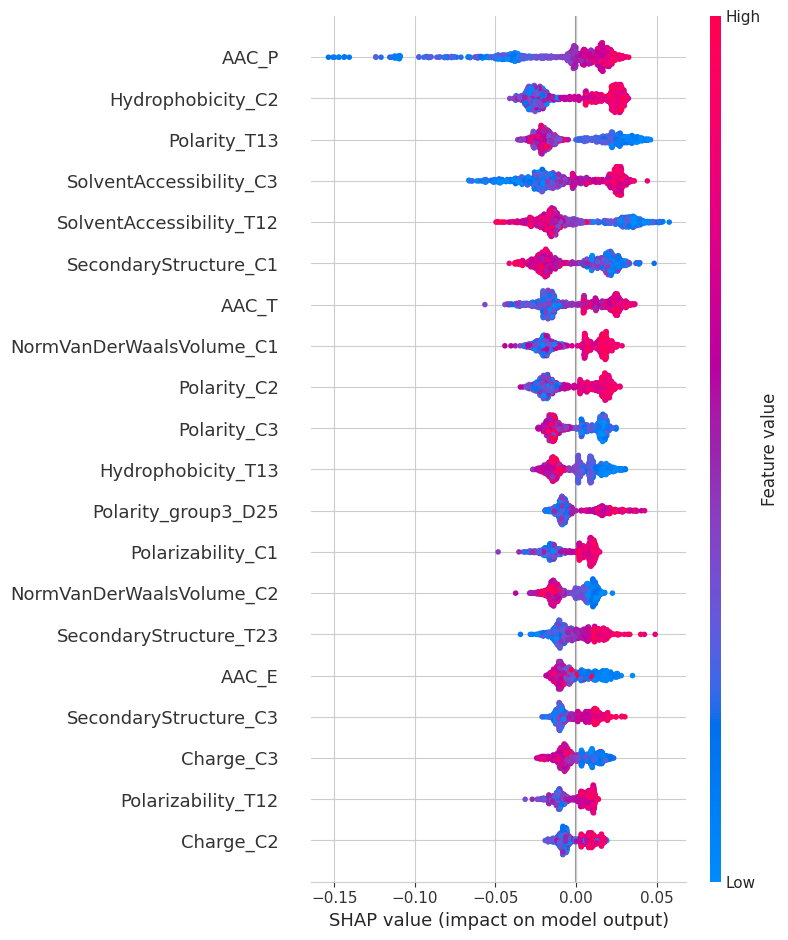

                 feature  mean_abs_shap  rf_gini_importance
                   AAC_P       0.024311            0.036212
       Hydrophobicity_C2       0.022742            0.034549
            Polarity_T13       0.022043            0.037983
 SolventAccessibility_C3       0.021568            0.037886
SolventAccessibility_T12       0.020903            0.035223
   SecondaryStructure_C1       0.019463            0.030219
                   AAC_T       0.019064            0.030996
NormVanDerWaalsVolume_C1       0.016952            0.026364
             Polarity_C2       0.016772            0.026464
             Polarity_C3       0.013913            0.025900
      Hydrophobicity_T13       0.012265            0.020367
     Polarity_group3_D25       0.011604            0.017743
       Polarizability_C1       0.011156            0.016904
NormVanDerWaalsVolume_C2       0.010964            0.015383
  SecondaryStructure_T23       0.010133            0.015278
                   AAC_E       0.010033 

In [15]:
#@title # 16. SHAP analysis - feature-level (direct biological interpretation)
# Same as Model #5: shap.TreeExplainer also supports RandomForestClassifier
# (not just XGBoost), so no change in approach is needed here.
#
# UNLIKE Model #1-4: AAC/CTD features are human-interpretable by
# construction (e.g. "% charged residues", "% buried hydrophobic
# residues"), so this SHAP analysis directly answers which physicochemical
# properties drive the prediction -- and can be compared against Model #5's
# XGBoost pattern on the same AAC/CTD features to see whether the two
# classifiers are "looking at" similar or different signal.

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_train_full)

# For RandomForestClassifier, the shape of shap_values varies depending on
# the shap library version:
#   - older versions: a list [shap_class0, shap_class1], each (n_samples, n_features)
#   - newer versions: a single 3D array (n_samples, n_features, n_classes)
# In both cases we take the contribution for the positive class (index 1).
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values_pos = shap_values[:, :, 1]
else:
    shap_values_pos = shap_values

print(f"shap_values_pos shape: {shap_values_pos.shape}")
assert shap_values_pos.ndim == 2, "shap_values_pos must be 2D (n_samples, n_features)"

plt.figure()
shap.summary_plot(shap_values_pos, X_train_full, feature_names=FEATURE_NAMES, show=False, max_display=20)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "shap_summary_features.png"), dpi=600, bbox_inches="tight")
plt.show()

mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:20]

importance_df = pd.DataFrame({
    "feature": [FEATURE_NAMES[i] for i in top_idx],
    "mean_abs_shap": mean_abs_shap[top_idx],
    "rf_gini_importance": final_model.feature_importances_[top_idx],
})
print(importance_df.to_string(index=False))
importance_df.to_csv(os.path.join(MODEL_OUT_DIR, "shap_top_features.csv"), index=False)


Fetching IsPETase (A0A0K8P6T7) from UniProt...
  Length: 290 aa
  Base predicted probability: 0.9996
  Known catalytic triad: [160, 206, 237]
    position 160: rank 253/290 (top 87.2%), delta=0.00000
    position 206: rank 261/290 (top 90.0%), delta=0.00000
    position 237: rank 151/290 (top 52.1%), delta=0.00000
  Top-15 predicted important positions: [26, 29, 39, 67, 72, 77, 113, 116, 140, 151, 189, 198, 266, 270, 279]
  Overlap with catalytic triad (top-15): [] (0/3)
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model6_aac_ctd_rf/reference_mutagenesis_ispetase_full_scan.xlsx
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model6_aac_ctd_rf/reference_mutagenesis_ispetase_full_scan.csv

  Alanine substitution vs full residue deletion (catalytic triad only):
 position residue  alanine_delta  deletion_delta
      160       S            0.0             0.0
      206       D            0.0             0.0
      237       H  

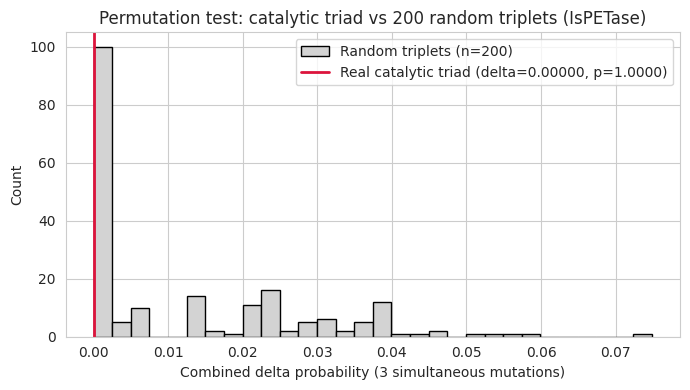


  Running windowed mutagenesis scan (window_size=7)... AAC/CTD features are cheap to recompute directly from the sequence string, so this is fast even for long sequences.
  Window-centered rank of catalytic positions (window_size=7):
    position 160: window-rank 221/290 (top 76.2%), window_delta=0.03563 (vs single-residue delta=0.00000)
    position 206: window-rank 98/290 (top 33.8%), window_delta=0.06822 (vs single-residue delta=0.00000)
    position 237: window-rank 276/290 (top 95.2%), window_delta=0.00231 (vs single-residue delta=0.00000)


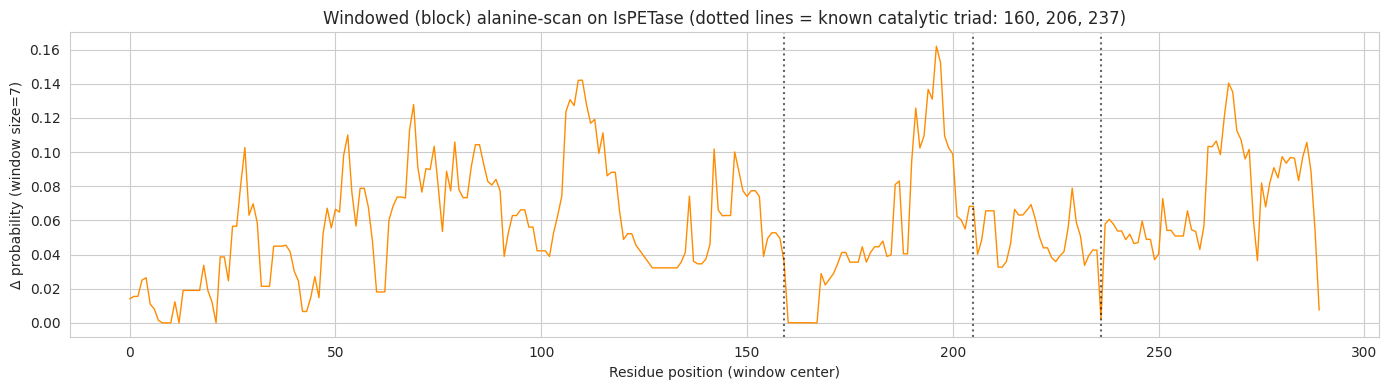

  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model6_aac_ctd_rf/reference_mutagenesis_ispetase_windowed_scan.xlsx
  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model6_aac_ctd_rf/reference_mutagenesis_ispetase_windowed_scan.csv


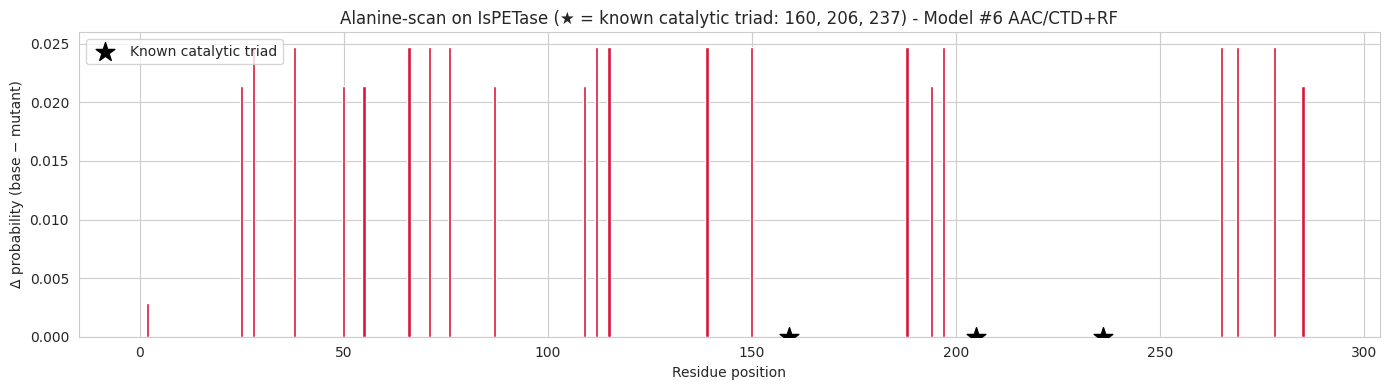

Fetching LCC (G9BY57) from UniProt...
  Length: 293 aa
  Base predicted probability: 0.9993
  Known catalytic triad: [165, 210, 242]
    position 165: rank 244/293 (top 83.3%), delta=0.00000
    position 210: rank 23/293 (top 7.8%), delta=0.00728
    position 242: rank 103/293 (top 35.2%), delta=0.00469
  Top-15 predicted important positions: [126, 197, 225, 239, 246, 248, 249, 266, 275, 276, 277, 278, 288, 289, 292]
  Overlap with catalytic triad (top-15): [] (0/3)
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model6_aac_ctd_rf/reference_mutagenesis_lcc_full_scan.xlsx
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model6_aac_ctd_rf/reference_mutagenesis_lcc_full_scan.csv

  Alanine substitution vs full residue deletion (catalytic triad only):
 position residue  alanine_delta  deletion_delta
      165       S       0.000000        0.039016
      210       D       0.007283        0.023692
      242       H       0.004692  

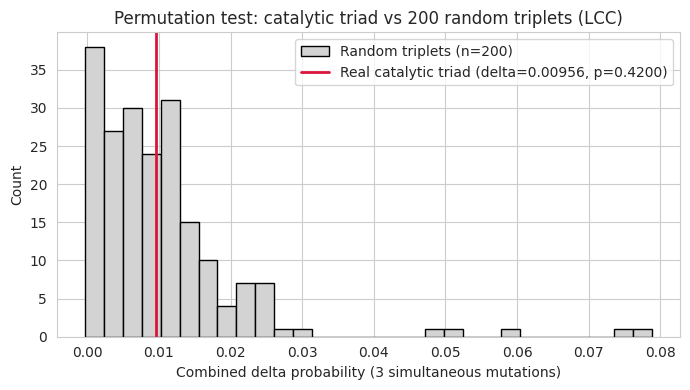


  Running windowed mutagenesis scan (window_size=7)... AAC/CTD features are cheap to recompute directly from the sequence string, so this is fast even for long sequences.
  Window-centered rank of catalytic positions (window_size=7):
    position 165: window-rank 278/293 (top 94.9%), window_delta=0.01017 (vs single-residue delta=0.00000)
    position 210: window-rank 252/293 (top 86.0%), window_delta=0.01916 (vs single-residue delta=0.00728)
    position 242: window-rank 231/293 (top 78.8%), window_delta=0.02979 (vs single-residue delta=0.00469)


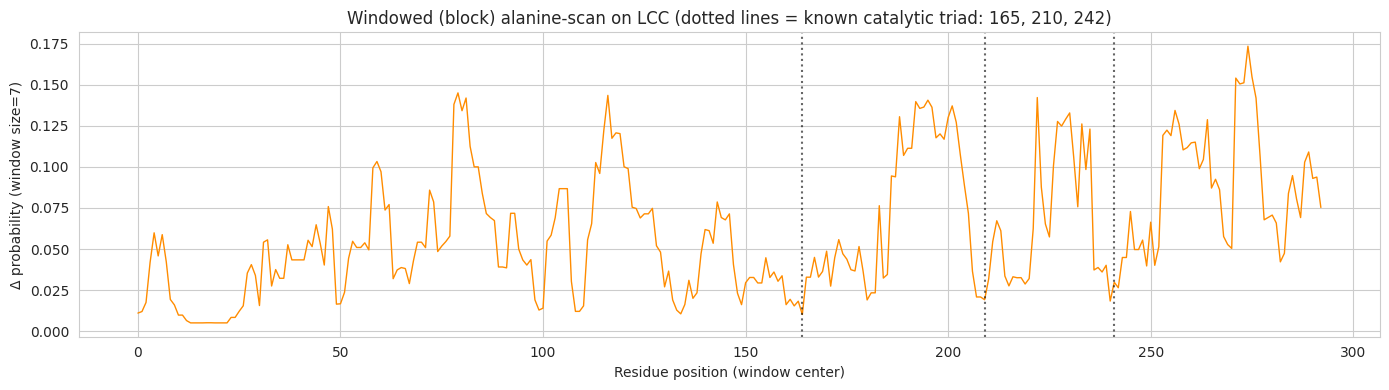

  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model6_aac_ctd_rf/reference_mutagenesis_lcc_windowed_scan.xlsx
  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model6_aac_ctd_rf/reference_mutagenesis_lcc_windowed_scan.csv


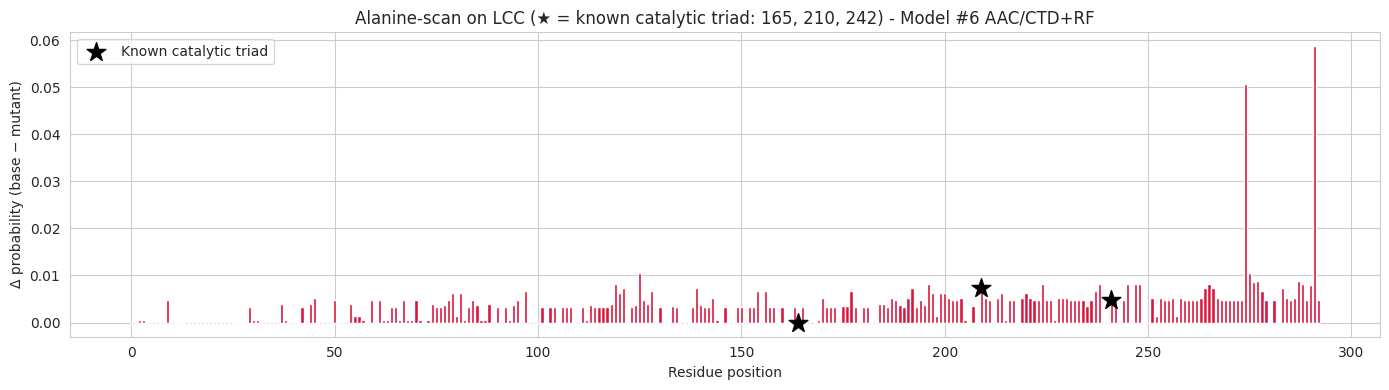

Fetching CalB_negative_control (P41365) from UniProt...
  Length: 342 aa
  Base predicted probability: 0.8446
  Known catalytic triad: [130, 212, 249]
    position 130: rank 213/342 (top 62.3%), delta=0.00276
    position 212: rank 221/342 (top 64.6%), delta=0.00230
    position 249: rank 77/342 (top 22.5%), delta=0.03477
  Top-15 predicted important positions: [180, 193, 207, 215, 230, 245, 246, 257, 263, 267, 274, 323, 327, 329, 334]
  Overlap with catalytic triad (top-15): [] (0/3)
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model6_aac_ctd_rf/reference_mutagenesis_calb_negative_control_full_scan.xlsx
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model6_aac_ctd_rf/reference_mutagenesis_calb_negative_control_full_scan.csv

  Alanine substitution vs full residue deletion (catalytic triad only):
 position residue  alanine_delta  deletion_delta
      130       S       0.002762        0.033512
      212       D       0.00

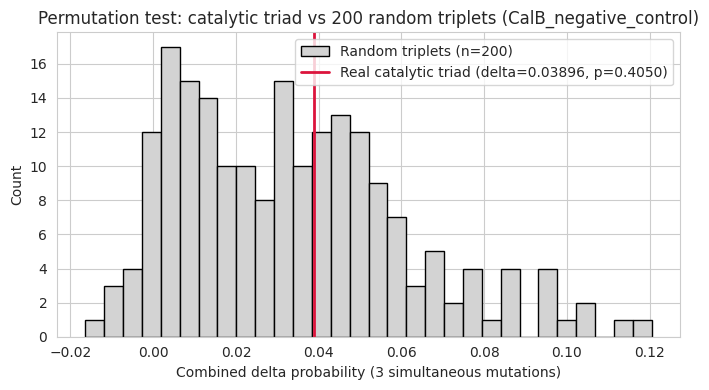


  Running windowed mutagenesis scan (window_size=7)... AAC/CTD features are cheap to recompute directly from the sequence string, so this is fast even for long sequences.
  Window-centered rank of catalytic positions (window_size=7):
    position 130: window-rank 245/342 (top 71.6%), window_delta=0.02953 (vs single-residue delta=0.00276)
    position 212: window-rank 144/342 (top 42.1%), window_delta=0.09390 (vs single-residue delta=0.00230)
    position 249: window-rank 142/342 (top 41.5%), window_delta=0.09680 (vs single-residue delta=0.03477)


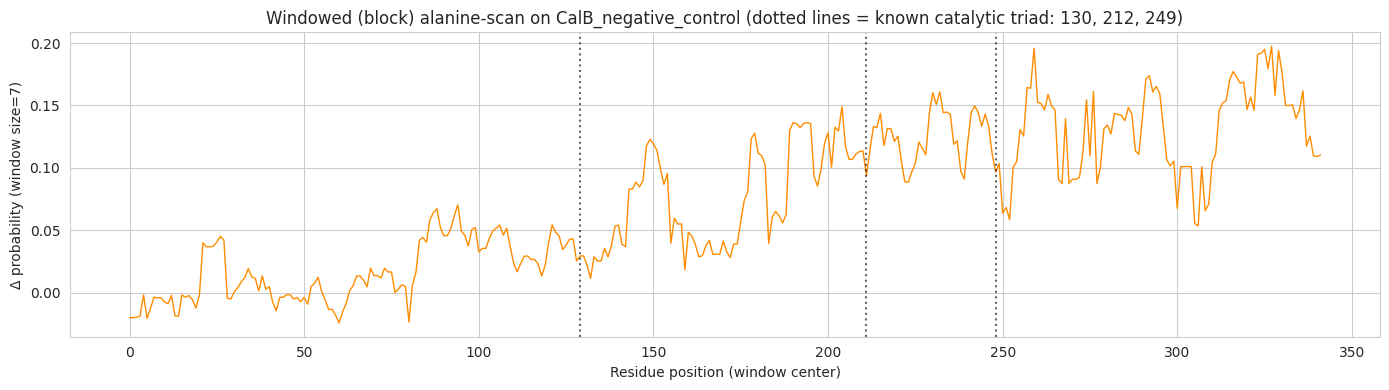

  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model6_aac_ctd_rf/reference_mutagenesis_calb_negative_control_windowed_scan.xlsx
  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model6_aac_ctd_rf/reference_mutagenesis_calb_negative_control_windowed_scan.csv


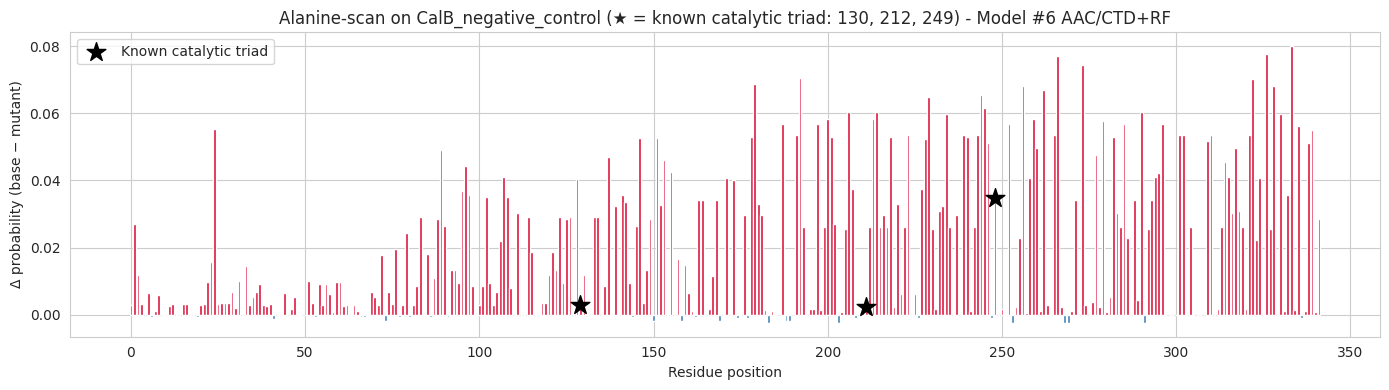


Saved reference scan results to /content/drive/MyDrive/InterPET/models/model6_aac_ctd_rf/reference_mutagenesis_results.pkl


In [7]:
#@title # 17. Fixed reference-sequence scan -- IsPETase active site (valid cross-model comparison)
# This section replaces the old "highest-confidence TP" demo (which picked a
# different, model-dependent sequence every time and was not usable for
# cross-model comparison). Instead we scan a FIXED reference sequence, chosen
# independently of any model's predictions, with a catalytic site already
# confirmed in the literature: IsPETase (Ideonella sakaiensis PETase),
# UniProt A0A0K8P6T7.
#
#   Catalytic triad: Ser160, Asp206, His237
#   (Yoshida et al. 2016, Science; Han et al. 2017, Nat. Commun., PDB 5XJH --
#   confirmed structurally and by site-directed mutagenesis; any substitution
#   at these positions abolishes catalytic activity.)
#
# Because every model notebook scans this exact same sequence, the top
# residues each model highlights can be directly compared, and checked
# against a real, experimentally-confirmed active site -- not just against
# each other.
#
# Methodologically identical to Model #5 -- mutagenesis_scan() only calls
# model.predict_proba(), so it is automatically compatible with Random
# Forest without any changes. No protein language model call is needed --
# AAC/CTD features are recomputed directly from the sequence string, so
# this scan is essentially instant.

!pip install -q openpyxl
import requests


def get_features_single(sequence):
    return compute_features(sequence)


def mutagenesis_scan(sequence, model, mutate_to="A"):
    """Return (base_proba, per_position_deltas) for a single sequence.
    delta[i] = base_proba - proba_after_mutating_position_i_to_`mutate_to`.
    A positive delta means residue i supports the positive-class prediction."""
    seq = sequence.strip().upper()
    base_feat = get_features_single(seq).reshape(1, -1)
    base_proba = model.predict_proba(base_feat)[0, 1]

    deltas = np.zeros(len(seq))
    for i, aa in enumerate(seq):
        if aa == mutate_to:
            deltas[i] = 0.0
            continue
        mutant_seq = seq[:i] + mutate_to + seq[i + 1:]
        mutant_feat = get_features_single(mutant_seq).reshape(1, -1)
        mutant_proba = model.predict_proba(mutant_feat)[0, 1]
        deltas[i] = base_proba - mutant_proba

    return base_proba, deltas


def windowed_mutagenesis_scan(sequence, model, window_size=7, mutate_to="A"):
    """Slide a contiguous window across the sequence, mutating the WHOLE
    window to alanine at once (rather than one residue at a time), and
    record the resulting delta at the window's center position.
    This can reveal regions that matter collectively even when no single
    residue inside them stands out on its own (i.e. individual mutations
    are below the mean-pooling noise floor, but a whole disrupted block
    is not)."""
    seq = sequence.strip().upper()
    n = len(seq)
    half = window_size // 2

    base_feat = get_features_single(seq).reshape(1, -1)
    base_proba = model.predict_proba(base_feat)[0, 1]

    window_deltas = np.zeros(n)
    for center in range(n):
        start = max(0, center - half)
        end = min(n, center + half + 1)
        mutant_seq = seq[:start] + mutate_to * (end - start) + seq[end:]
        mutant_feat = get_features_single(mutant_seq).reshape(1, -1)
        mutant_proba = model.predict_proba(mutant_feat)[0, 1]
        window_deltas[center] = base_proba - mutant_proba

    return base_proba, window_deltas


REFERENCE_SEQUENCES = {
    "IsPETase": {
        "uniprot_id": "A0A0K8P6T7",
        "source": "Yoshida et al. 2016 Science; Han et al. 2017 Nat Commun (PDB 5XJH)",
        "catalytic_triad_positions": [160, 206, 237],  # Ser160, Asp206, His237 (1-indexed)
        "expected_residues": {160: "S", 206: "D", 237: "H"},
        "is_petase": True,
    },
    "LCC": {
        "uniprot_id": "G9BY57",
        "source": "Sulaiman et al. 2012 Appl Environ Microbiol; Tournier et al. 2020 Nature (PDB 4EB0)",
        "catalytic_triad_positions": [165, 210, 242],  # Ser165, Asp210, His242 (1-indexed)
        "expected_residues": {165: "S", 210: "D", 242: "H"},
        "is_petase": True,
    },
    "CalB_negative_control": {
        "uniprot_id": "P41365",
        "source": "Uppenberg et al. 1994 Structure (PDB 1TCA) -- Candida antarctica Lipase B, "
                   "NOT PET-active; same catalytic mechanism/fold family as PETases, used as "
                   "a functional-specificity negative control",
        "catalytic_triad_positions": [130, 212, 249],  # Ser130, Asp212, His249 (1-indexed)
        "expected_residues": {130: "S", 212: "D", 249: "H"},
        "is_petase": False,
    },
}


def fetch_uniprot_sequence(uniprot_id):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    lines = resp.text.strip().split("\n")
    return "".join(lines[1:])  # drop the ">header" line


reference_scan_results = {}

for ref_name, ref_info in REFERENCE_SEQUENCES.items():
    print(f"Fetching {ref_name} ({ref_info['uniprot_id']}) from UniProt...")
    ref_seq = fetch_uniprot_sequence(ref_info["uniprot_id"])
    print(f"  Length: {len(ref_seq)} aa")

    base_p, deltas = mutagenesis_scan(ref_seq, final_model)
    print(f"  Base predicted probability: {base_p:.4f}")

    top_n = 15
    order = np.argsort(deltas)[::-1]
    top_positions = set((order[:top_n] + 1).tolist())  # 1-indexed
    known_positions = set(ref_info["catalytic_triad_positions"])
    overlap = known_positions & top_positions

    rank_of = {pos: int(np.where(order == (pos - 1))[0][0]) + 1 for pos in known_positions}
    n_total = len(deltas)
    print(f"  Known catalytic triad: {sorted(known_positions)}")
    for pos in sorted(known_positions):
        pct_from_top = 100 * rank_of[pos] / n_total
        print(f"    position {pos}: rank {rank_of[pos]}/{n_total} (top {pct_from_top:.1f}%), delta={deltas[pos-1]:.5f}")
    print(f"  Top-{top_n} predicted important positions: {sorted(top_positions)}")
    print(f"  Overlap with catalytic triad (top-{top_n}): {sorted(overlap)} ({len(overlap)}/{len(known_positions)})")

    # ---- Export full per-residue delta table to Excel + CSV ----
    full_scan_df = pd.DataFrame({
        "position": np.arange(1, len(ref_seq) + 1),
        "residue": list(ref_seq),
        "delta_proba": deltas,
        "is_known_catalytic_residue": [p in known_positions for p in range(1, len(ref_seq) + 1)],
    }).sort_values("delta_proba", ascending=False).reset_index(drop=True)

    excel_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_full_scan.xlsx")
    csv_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_full_scan.csv")
    full_scan_df.to_excel(excel_path, index=False, sheet_name="alanine_scan")
    full_scan_df.to_csv(csv_path, index=False)
    print(f"  Saved full per-residue delta table to {excel_path}")
    print(f"  Saved full per-residue delta table to {csv_path}")

    # ---- Variation 1: residue DELETION vs alanine substitution, at the 3 known positions only ----
    # ESM-2/ProtT5 notebooks compare alanine substitution against a language-
    # model-specific "masked/unknown residue" token. AAC/CTD features have no
    # such token -- but because they are computed directly from the sequence
    # string, we can cleanly probe a perturbation embedding models can't:
    # fully DELETING the residue (shortening the sequence by one) instead of
    # replacing it with alanine. This tests whether a residue's importance
    # comes from WHICH amino acid sits at that position (captured by alanine
    # substitution) or merely from its presence in the composition/length
    # statistics (captured by deletion).
    deletion_comparison = []
    for pos in sorted(known_positions):
        deleted_seq = ref_seq[:pos - 1] + ref_seq[pos:]
        del_feat = get_features_single(deleted_seq).reshape(1, -1)
        del_proba = final_model.predict_proba(del_feat)[0, 1]
        del_delta = base_p - del_proba
        deletion_comparison.append({
            "position": pos,
            "residue": ref_seq[pos - 1],
            "alanine_delta": deltas[pos - 1],
            "deletion_delta": del_delta,
        })

    deletion_comparison_df = pd.DataFrame(deletion_comparison)
    print("\n  Alanine substitution vs full residue deletion (catalytic triad only):")
    print(deletion_comparison_df.to_string(index=False))

    # ---- Variation 2: combined (simultaneous) triple mutation vs sum of individual deltas ----
    seq_list = list(ref_seq)
    for pos in known_positions:
        seq_list[pos - 1] = "A"
    combined_mutant_seq = "".join(seq_list)
    combined_feat = get_features_single(combined_mutant_seq).reshape(1, -1)
    combined_proba = final_model.predict_proba(combined_feat)[0, 1]
    combined_delta = base_p - combined_proba
    sum_individual_deltas = sum(deltas[pos - 1] for pos in known_positions)

    print(f"\n  Combined triple-mutation (all 3 catalytic residues -> Ala simultaneously):")
    print(f"    proba after combined mutation : {combined_proba:.4f}")
    print(f"    combined delta                : {combined_delta:.5f}")
    print(f"    sum of individual deltas       : {sum_individual_deltas:.5f}")
    print(f"    synergy (combined - sum)        : {combined_delta - sum_individual_deltas:.5f}")

    # ---- Variation 2b: permutation test for the combined-mutation synergy ----
    # Is the combined delta actually special, or would mutating ANY random
    # triplet of positions simultaneously tend to produce a similarly large
    # delta (since disturbing 3 positions at once is inherently a bigger
    # perturbation than disturbing 1)? We build a null distribution from
    # random triplets (excluding the real triad) and see where the real
    # triad's combined delta falls within it.
    n_permutations = 200
    rng = np.random.default_rng(RANDOM_SEED)
    all_positions = np.arange(1, len(ref_seq) + 1)
    candidate_positions = np.setdiff1d(all_positions, list(known_positions))

    null_deltas = np.zeros(n_permutations)
    for p_i in range(n_permutations):
        rand_positions = rng.choice(candidate_positions, size=len(known_positions), replace=False)
        seq_list_rand = list(ref_seq)
        for pos in rand_positions:
            seq_list_rand[pos - 1] = "A"
        rand_mutant_seq = "".join(seq_list_rand)
        rand_feat = get_features_single(rand_mutant_seq).reshape(1, -1)
        rand_proba = final_model.predict_proba(rand_feat)[0, 1]
        null_deltas[p_i] = base_p - rand_proba
        if (p_i + 1) % 50 == 0:
            print(f"    permutation {p_i + 1}/{n_permutations}...")

    p_value = float(np.mean(null_deltas >= combined_delta))
    z_score = float((combined_delta - null_deltas.mean()) / (null_deltas.std() + 1e-12))

    print(f"\n  Permutation test (n={n_permutations} random triplets of positions, "
          f"excluding the real catalytic triad):")
    print(f"    null distribution -- mean={null_deltas.mean():.5f}, std={null_deltas.std():.5f}, "
          f"max={null_deltas.max():.5f}")
    print(f"    observed combined delta (real catalytic triad): {combined_delta:.5f}")
    print(f"    empirical p-value (P[null >= observed]): {p_value:.4f}")
    print(f"    z-score: {z_score:.3f}")

    plt.figure(figsize=(7, 4))
    plt.hist(null_deltas, bins=30, color="lightgray", edgecolor="black", label=f"Random triplets (n={n_permutations})")
    plt.axvline(combined_delta, color="crimson", linewidth=2,
                label=f"Real catalytic triad (delta={combined_delta:.5f}, p={p_value:.4f})")
    plt.xlabel("Combined delta probability (3 simultaneous mutations)")
    plt.ylabel("Count")
    plt.title(f"Permutation test: catalytic triad vs {n_permutations} random triplets ({ref_name})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_permutation_test.png"), dpi=600)
    plt.show()

    pd.DataFrame({"null_delta": null_deltas}).to_csv(
        os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_permutation_null.csv"), index=False
    )

    # ---- Variation 3: windowed/block mutagenesis ----
    window_size = 7
    print(f"\n  Running windowed mutagenesis scan (window_size={window_size})... AAC/CTD features are cheap to recompute directly from the sequence string, so this is fast even for long sequences.")
    _, window_deltas = windowed_mutagenesis_scan(ref_seq, final_model, window_size=window_size)

    window_order = np.argsort(window_deltas)[::-1]
    print(f"  Window-centered rank of catalytic positions (window_size={window_size}):")
    for pos in sorted(known_positions):
        w_rank = int(np.where(window_order == (pos - 1))[0][0]) + 1
        w_pct = 100 * w_rank / n_total
        print(f"    position {pos}: window-rank {w_rank}/{n_total} (top {w_pct:.1f}%), "
              f"window_delta={window_deltas[pos-1]:.5f} (vs single-residue delta={deltas[pos-1]:.5f})")

    plt.figure(figsize=(14, 4))
    plt.plot(range(len(window_deltas)), window_deltas, color="darkorange", linewidth=1)
    for pos in known_positions:
        plt.axvline(pos - 1, color="black", linestyle=":", alpha=0.6)
    plt.xlabel("Residue position (window center)")
    plt.ylabel(f"Δ probability (window size={window_size})")
    plt.title(f"Windowed (block) alanine-scan on {ref_name} "
              f"(dotted lines = known catalytic triad: {', '.join(str(p) for p in sorted(known_positions))})")
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_windowed.png"), dpi=600)
    plt.show()

    window_scan_df = pd.DataFrame({
        "position": np.arange(1, len(ref_seq) + 1),
        "residue": list(ref_seq),
        "window_delta_proba": window_deltas,
        "single_residue_delta_proba": deltas,
        "is_known_catalytic_residue": [p in known_positions for p in range(1, len(ref_seq) + 1)],
    }).sort_values("window_delta_proba", ascending=False).reset_index(drop=True)
    window_excel_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_windowed_scan.xlsx")
    window_csv_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_windowed_scan.csv")
    window_scan_df.to_excel(window_excel_path, index=False, sheet_name=f"window{window_size}_scan")
    window_scan_df.to_csv(window_csv_path, index=False)
    print(f"  Saved windowed scan table to {window_excel_path}")
    print(f"  Saved windowed scan table to {window_csv_path}")

    reference_scan_results[ref_name] = {
        "sequence": ref_seq,
        "base_proba": base_p,
        "deltas": deltas,
        "window_deltas": window_deltas,
        "window_size": window_size,
        "top_positions": sorted(top_positions),
        "known_catalytic_triad": sorted(known_positions),
        "overlap_with_catalytic_triad": sorted(overlap),
        "rank_of_known_positions": rank_of,
        "deletion_vs_alanine_comparison": deletion_comparison,
        "combined_triple_mutation_delta": combined_delta,
        "sum_of_individual_deltas": sum_individual_deltas,
        "permutation_test_null_deltas": null_deltas,
        "permutation_test_p_value": p_value,
        "permutation_test_z_score": z_score,
    }

    plt.figure(figsize=(14, 4))
    colors = ["crimson" if d > 0 else "steelblue" for d in deltas]
    plt.bar(range(len(deltas)), deltas, color=colors)
    for pos in known_positions:
        plt.scatter([pos - 1], [deltas[pos - 1]], marker="*", s=200,
                    color="black", zorder=5,
                    label="Known catalytic triad" if pos == min(known_positions) else None)
    plt.xlabel("Residue position")
    plt.ylabel("Δ probability (base − mutant)")
    plt.title(f"Alanine-scan on {ref_name} (★ = known catalytic triad: "
              f"{', '.join(str(p) for p in sorted(known_positions))}) - Model #6 AAC/CTD+RF")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}.png"), dpi=600)
    plt.show()

with open(os.path.join(MODEL_OUT_DIR, "reference_mutagenesis_results.pkl"), "wb") as f:
    pickle.dump(reference_scan_results, f)

print(f"\nSaved reference scan results to {MODEL_OUT_DIR}/reference_mutagenesis_results.pkl")


In [ ]:
#@title # 18. Top-15 residues for the top-3 highest-confidence benchmark sequences
# Selection criterion here is purely the model's own predicted probability
# (base_proba on the benchmark set) -- the 3 sequences the model is most
# confident about, regardless of TP/FP/FN status. mutagenesis_scan() was
# already defined in the previous section, so it's reused as-is here
# (AAC/CTD feature recomputation instead of a language-model embedding call, Random Forest instead of XGBoost).

top3_rows = np.argsort(y_bench_proba)[::-1][:3]
print(f"Top-3 benchmark rows by base_proba: {list(top3_rows)}")

excel_path = os.path.join(MODEL_OUT_DIR, "batch_mutagenesis_top15_top3rows.xlsx")
top15_summary = []

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for row in top3_rows:
        seq = df_bench.iloc[row]["sequence"]
        base_p, deltas = mutagenesis_scan(seq, final_model)

        top15_idx = np.argsort(deltas)[::-1][:15]
        row_df = pd.DataFrame({
            "position": top15_idx + 1,  # 1-indexed
            "residue": [seq[i] for i in top15_idx],
            "delta_proba": deltas[top15_idx],
        })
        row_df.insert(0, "benchmark_row", row)
        row_df.insert(1, "base_proba", base_p)

        sheet_name = f"row_{row}"[:31]  # Excel sheet name limit
        row_df.to_excel(writer, index=False, sheet_name=sheet_name)
        top15_summary.append(row_df)

        print(f"\nRow {row} (base_proba={base_p:.4f}) -- top 15 residues:")
        print(row_df[["position", "residue", "delta_proba"]].to_string(index=False))

print(f"\nSaved top-15 tables for top-3 benchmark rows to {excel_path}")

top15_summary_df = pd.concat(top15_summary, ignore_index=True)
top15_summary_df.to_csv(os.path.join(MODEL_OUT_DIR, "batch_mutagenesis_top15_top3rows.csv"), index=False)


Top-3 benchmark rows by base_proba: [np.int64(8), np.int64(16), np.int64(25)]

Row 8 (base_proba=0.9587) -- top 15 residues:
 position residue  delta_proba
       99       W     0.013079
        1       M     0.009076
      204       D     0.008931
      121       D     0.008931
      261       D     0.006936
      206       D     0.006936
      263       D     0.006936
      150       D     0.006936
      193       D     0.006936
      126       R     0.006263
        8       R     0.006263
        9       R     0.006263
       12       R     0.005691
      102       R     0.004829
      103       R     0.004829

Row 16 (base_proba=0.9296) -- top 15 residues:
 position residue  delta_proba
      286       C     0.061256
      289       T     0.061036
      246       T     0.059037
      285       T     0.059037
      263       T     0.059037
      270       C     0.056489
       40       T     0.056374
       81       T     0.056374
      195       T     0.055704
      197       T    